# Field-Retrieval Analysis

Analysis code accompanying **"All-Optical Field-Resolved Spectroscopy With
Interferometric Nonlinear Cross-Correlations"**
([arXiv:2608.04493](https://arxiv.org/abs/2608.04493)).

The notebook reproduces the field-retrieval figures directly from the measured
data: the D-Scan reference pulse, the effective detection transfer functions of
the third- (N = 3) and fifth-order (N = 5) nonlinear cross-correlation, the
retrieved time-domain fields, spectra and spectral phases against the D-Scan and
OSA references, and the time-frequency (spectrogram) analysis.

Run the cells top to bottom. Figures are written to `./figures/`.

## Data

Everything the notebook needs is in `data/field_retrieval_data.h5`:

| Group | Contents |
| --- | --- |
| `dscan/{signal,gate}/` | `time` (s), `field_complex` — D-Scan retrieval of the pulse under test and of the gate pulse |
| `electric_field_traces/<method>/<triplet_i>/` | `time` (s), `up_field_centered_filtered` — retrieved electric fields. `method1_550` = 5th order (N = 5), `method3_thg` = 3rd order (N = 3), `method2_antenna` = antenna reference. The figures below use `triplet_0` |
| `osa/<trace>/` | `wavelength_nm`, `power_dBm` — OSA spectra. `20250610_SIGCLIP` is the reference trace, `noise_floor` the instrument detection floor (2 nm resolution, 10 averages) |
| `spectrometer/` | `wavelength` (m), `intensity` — fundamental spectrum |

`data/dscan_signal.txt` and `data/dscan_gate.txt` are the original D-Scan text
exports (`time [fs], Re(E), Im(E), normalized intensity`) from which the
`dscan/` group was built; they are included for provenance only.

## Requirements

`numpy`, `scipy`, `matplotlib`, `h5py`, and — for the manuscript figure style —
`scienceplots` (optional; the notebook falls back to the matplotlib defaults).
See `requirements.txt`.

In [1]:
# =============================================================================
# IMPORTS AND PLOT CONFIGURATION
# =============================================================================
import os

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import stft, get_window

# Optional: manuscript figure style
try:
    import scienceplots  # noqa: F401  (registers the styles with matplotlib)
    plt.style.use(['science', 'nature', 'retro'])
except ImportError:
    print("scienceplots not installed, using default matplotlib style")

# Editable text in vector output (Illustrator-friendly)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['text.usetex'] = False

# Arial everywhere, including math
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

# Honor figsize on export (scienceplots otherwise sets savefig.bbox="tight",
# which crops every PDF/PNG to content and shrinks it below the intended size)
matplotlib.rcParams['savefig.bbox'] = 'standard'

# Font sizes (pt) and line widths used throughout
SMALL_SIZE = 6
MEDIUM_SIZE = 7
BIGGER_SIZE = 8
def_linewidth = 1
axLabelPad = 4
dpi_export = 800

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE, labelsize=MEDIUM_SIZE, labelpad=axLabelPad)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)
plt.rc('lines', linewidth=def_linewidth)

# Dash patterns referenced by index below (index 1 = dotted, 2 = densely dotted)
linestyle_tuple = [
    ('loosely dotted',         (0, (1, 10))),
    ('dotted',                 (0, (1, 5))),
    ('densely dotted',         (0, (1, 1))),
    ('long dash with offset',  (5, (10, 3))),
    ('loosely dashed',         (0, (5, 10))),
    ('dashed',                 (0, (5, 5))),
    ('densely dashed',         (0, (5, 1))),
    ('loosely dashdotted',     (0, (3, 10, 1, 10))),
    ('dashdotted',             (0, (3, 5, 1, 5))),
    ('densely dashdotted',     (0, (3, 1, 1, 1))),
    ('dashdotdotted',          (0, (3, 5, 1, 5, 1, 5))),
    ('loosely dashdotdotted',  (0, (3, 10, 1, 10, 1, 10))),
    ('densely dashdotdotted',  (0, (3, 1, 1, 1, 1, 1))),
]
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

cm = 1 / 2.54          # cm -> inches, for figsize
c = 299792458.0        # speed of light (m/s)

saveplots = True
saveFigDir = './figures/'
os.makedirs(saveFigDir, exist_ok=True)

print("Configuration complete!")

Configuration complete!


## Data loading

All measured data lives in the single HDF5 file `data/field_retrieval_data.h5`.
The D-Scan traces in it come from the corrected 2026-02-03 retrieval, which is
the one used throughout the manuscript.

In [2]:
# =============================================================================
# LOAD THE MEASURED DATA
# =============================================================================
data_file_path = './data/field_retrieval_data.h5'
if not os.path.exists(data_file_path):
    raise FileNotFoundError(f"Could not find {data_file_path}. CWD={os.getcwd()}")

print(f"Loading data from: {data_file_path}\n")

with h5py.File(data_file_path, 'r') as f:
    print("File metadata:")
    for key, val in f.attrs.items():
        print(f"  {key}: {val}")
    print()

    # --- D-Scan retrieval (reference pulse and gate) ---
    dscan_time = f['dscan/signal/time'][()]                     # s
    dscan_field_complex = f['dscan/signal/field_complex'][()]
    dscan_gate_time = f['dscan/gate/time'][()]                  # s
    dscan_gate_field_complex = f['dscan/gate/field_complex'][()]
    print(f"D-Scan signal: {len(dscan_time)} points")
    print(f"D-Scan gate:   {len(dscan_gate_time)} points")

    # --- Fundamental spectrum ---
    spec_wavelength = f['spectrometer/wavelength'][()]
    spec_intensity = f['spectrometer/intensity'][()]
    print(f"Spectrometer: {len(spec_wavelength)} points")

    # --- OSA traces ---
    osa_data = {
        name: {
            'wavelength_nm': f[f'osa/{name}/wavelength_nm'][()],
            'power_dBm': f[f'osa/{name}/power_dBm'][()],
        }
        for name in f['osa'].keys()
    }
    print(f"OSA traces: {list(osa_data.keys())}")

    # --- Retrieved electric-field traces, per detection method and triplet ---
    efield_data = {}
    method_labels = {}
    for method in f['electric_field_traces'].keys():
        method_grp = f[f'electric_field_traces/{method}']
        method_labels[method] = method_grp.attrs['label']
        efield_data[method] = {
            triplet: {
                'time': method_grp[triplet]['time'][()],
                'field': method_grp[triplet]['up_field_centered_filtered'][()],
                'attrs': dict(method_grp[triplet].attrs),
            }
            for triplet in method_grp.keys()
        }

    print("\nElectric-field methods:")
    for method, label in method_labels.items():
        print(f"  {method} ('{label}'): {len(efield_data[method])} triplets")

print("\nData loading complete!")

Loading data from: ./data/field_retrieval_data.h5

File metadata:
  created: 2026-08-18T14:59:23+00:00
  description: Measured data for the field-retrieval analysis of 'All-Optical Field-Resolved Spectroscopy With Interferometric Nonlinear Cross-Correlations' (arXiv:2608.04493).
  source_notebook: AnalysisFromExport_saugened.ipynb

D-Scan signal: 1228 points
D-Scan gate:   1465 points
Spectrometer: 255 points
OSA traces: ['20250610_SIG', '20250610_SIG2', '20250610_SIGCLIP', '20250610_SIGCLIP2', 'noise_floor']

Electric-field methods:
  method1_550 ('550'): 3 triplets
  method2_antenna ('Antenna'): 3 triplets
  method3_thg ('THG'): 3 triplets

Data loading complete!


## D-Scan reference pulse

Temporal intensity of the D-Scan-retrieved signal and gate pulses. The gate is
the pulse that drives the nonlinear cross-correlation; the signal is the pulse
under test.

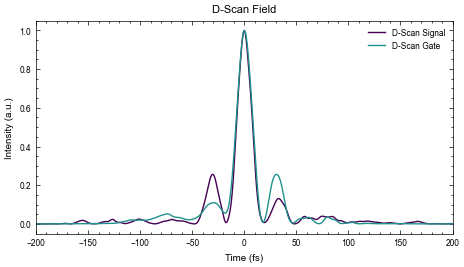

In [3]:
# =============================================================================
# FIGURE: D-SCAN TEMPORAL INTENSITY (SIGNAL AND GATE)
# =============================================================================
method_colors = plt.cm.viridis(np.linspace(0, 1, 3))

fig, ax = plt.subplots(figsize=(cm * 12, cm * 7))

dscan_intensity = np.abs(dscan_field_complex) ** 2
ax.plot(dscan_time * 1e15, dscan_intensity / dscan_intensity.max(),
        label='D-Scan Signal', color=method_colors[0])

gate_intensity = np.abs(dscan_gate_field_complex) ** 2
ax.plot(dscan_gate_time * 1e15, gate_intensity / gate_intensity.max(),
        label='D-Scan Gate', color=method_colors[1])

ax.set_xlabel('Time (fs)')
ax.set_ylabel('Intensity (a.u.)')
ax.set_xlim(-200, 200)
ax.set_title('D-Scan Field')
ax.legend()

plt.tight_layout()
if saveplots:
    plt.savefig(f'{saveFigDir}dscan_field_signal_gate.pdf')
    plt.savefig(f'{saveFigDir}dscan_field_signal_gate.png', dpi=dpi_export)
plt.show()

## Detection transfer function

For an *N*-th order cross-correlation the measured signal is the field under
test convolved with the gate response

$$ g_N(t) = E_g(t)\,\bigl|E_g(t)\bigr|^{2(N-1)} , $$

so the effective detection transfer function is $H_N(\omega) = \mathcal{F}\{g_N\}$.
The panel below compares $|H(\omega)|^2$ and $\arg H(\omega)$ for $N = 3$ and
$N = 5$: the higher-order gate is shorter in time and therefore supports a
broader detection bandwidth.

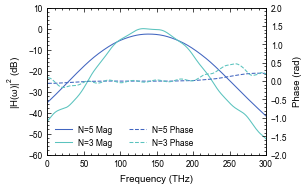

Gate N=3 above -30.0 dB between 0.05 PHz and 0.24 PHz
Gate N=5 above -30.0 dB between 0.01 PHz and 0.27 PHz


In [4]:
# =============================================================================
# FIGURE: GATE TRANSFER FUNCTIONS FOR N = 3 AND N = 5
# =============================================================================

# Gate response g_N(t) = E_g(t) * |E_g(t)|^{2(N-1)}
normCmplxDscanGate = dscan_gate_field_complex / np.max(np.abs(dscan_gate_field_complex))
n5_gate = normCmplxDscanGate * np.abs(normCmplxDscanGate ** 4) ** 2
n3_gate = normCmplxDscanGate * np.abs(normCmplxDscanGate ** 2) ** 2

fft_n_gate = len(n5_gate)
fft_n5_gate = np.fft.fft(np.fft.ifftshift(n5_gate), n=fft_n_gate)
fft_n3_gate = np.fft.fft(np.fft.ifftshift(n3_gate), n=fft_n_gate)

dt_gate = dscan_gate_time[1] - dscan_gate_time[0]
freq_gate = np.fft.fftfreq(fft_n_gate, dt_gate)


def get_corrected_phase_tf_posonly(fft_signal, freq_hz, fit_min_hz, fit_max_hz):
    """Unwrapped spectral phase on positive frequencies, with the linear
    (group-delay) term fitted over [fit_min_hz, fit_max_hz] removed."""
    pos = freq_hz > 0
    sort_idx = np.argsort(freq_hz[pos])
    f = freq_hz[pos][sort_idx]
    phase = np.unwrap(np.angle(fft_signal[pos][sort_idx]))

    fit_idx = np.where((f >= fit_min_hz) & (f <= fit_max_hz))[0]
    if fit_idx.size >= 2:
        coeffs = np.polyfit(f[fit_idx], phase[fit_idx], 1)
        phase = phase - np.polyval(coeffs, f)

    return f * 1e-12, phase          # THz, rad


def get_bounds(H_mag, freq_thz, thresh_db, ix_peak):
    """Frequencies where H_mag first drops below thresh_db either side of ix_peak."""
    thresh = np.max(H_mag) * (10 ** (thresh_db / 10))
    hi = np.where(H_mag[ix_peak:] <= thresh)[0]
    lo = np.flip(np.where(H_mag[0:ix_peak] <= thresh))[0]
    hi_idx = hi[0] + ix_peak if len(hi) > 0 else len(H_mag) - 1
    lo_idx = lo[0] if len(lo) > 0 else 0
    return freq_thz[lo_idx], freq_thz[hi_idx]


# Detrend the phase over the spectral region where the pulse carries energy
phase_fit_wl_min, phase_fit_wl_max = 1.75e-6, 2.6e-6
f_min_hz, f_max_hz = c / phase_fit_wl_max, c / phase_fit_wl_min

freq_thz_gate, phase_n5_gate = get_corrected_phase_tf_posonly(
    fft_n5_gate, freq_gate, f_min_hz, f_max_hz)
_, phase_n3_gate = get_corrected_phase_tf_posonly(
    fft_n3_gate, freq_gate, f_min_hz, f_max_hz)

# Magnitudes on positive frequencies, both normalized to the common peak
H_mag_n5_gate = np.abs(fft_n5_gate[freq_gate > 0]) ** 2
H_mag_n3_gate = np.abs(fft_n3_gate[freq_gate > 0]) ** 2
norm_gate = max(np.max(H_mag_n5_gate), np.max(H_mag_n3_gate))
H_mag_n5_gatenorm_dB = 10 * np.log10(H_mag_n5_gate / norm_gate)
H_mag_n3_gatenorm_dB = 10 * np.log10(H_mag_n3_gate / norm_gate)

thresh_pwr_dB = -30.0
gate_peak_ix = np.argmax(H_mag_n5_gate)
b3_lo_gate, b3_hi_gate = get_bounds(H_mag_n3_gate, freq_thz_gate, thresh_pwr_dB, gate_peak_ix)
b5_lo_gate, b5_hi_gate = get_bounds(H_mag_n5_gate, freq_thz_gate, thresh_pwr_dB, gate_peak_ix)

fig, ax = plt.subplots(figsize=(8 * cm, 5 * cm))
ax2 = ax.twinx()

# N = 5 -> cycle_colors[0], N = 3 -> cycle_colors[2] (matches the combined figures)
line1, = ax.plot(freq_thz_gate, H_mag_n5_gatenorm_dB, label='N=5 Mag', color=cycle_colors[0], lw=0.75)
line2, = ax.plot(freq_thz_gate, H_mag_n3_gatenorm_dB, label='N=3 Mag', color=cycle_colors[2], lw=0.75)
line3, = ax2.plot(freq_thz_gate, phase_n5_gate, label='N=5 Phase', color=cycle_colors[0], lw=0.75, ls='--')
line4, = ax2.plot(freq_thz_gate, phase_n3_gate, label='N=3 Phase', color=cycle_colors[2], lw=0.75, ls='--')

ax.set_xlim(0, 300)
ax.set_ylim(-60, 10)
ax2.set_ylim(-2, 2)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel(r'$|H(\omega)|^2$ (dB)')
ax2.set_ylabel('Phase (rad)')
ax.legend([line1, line2, line3, line4], [l.get_label() for l in (line1, line2, line3, line4)],
          loc='lower left', frameon=False, fontsize=SMALL_SIZE, ncol=2)

plt.tight_layout()
if saveplots:
    plt.savefig(f'{saveFigDir}Gate_magnitude.pdf')
    plt.savefig(f'{saveFigDir}Gate_magnitude.png', dpi=dpi_export)
plt.show()

print(f"Gate N=3 above {thresh_pwr_dB} dB between {b3_lo_gate/1000:.2f} PHz and {b3_hi_gate/1000:.2f} PHz")
print(f"Gate N=5 above {thresh_pwr_dB} dB between {b5_lo_gate/1000:.2f} PHz and {b5_hi_gate/1000:.2f} PHz")

## Retrieved pulse: comparison against the D-Scan reference

`method1_550` is the fifth-order (N = 5) cross-correlation and `method3_thg` the
third-order (N = 3) one. Each trace is peak-centred and normalized before
comparison with the D-Scan envelope.

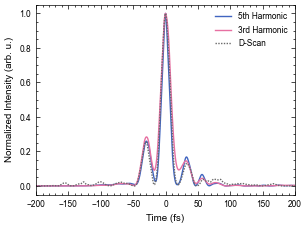

In [5]:
# =============================================================================
# FIGURE: RETRIEVED TEMPORAL INTENSITY, N = 3 vs N = 5 vs D-SCAN
# =============================================================================
triplet_index = 0
triplet_key = f'triplet_{triplet_index}'

fig, ax = plt.subplots(figsize=(cm * 8, cm * 6))

for method, label_ in [('method1_550', '5th Harmonic'), ('method3_thg', '3rd Harmonic')]:
    if triplet_key not in efield_data[method]:
        continue
    data = efield_data[method][triplet_key]
    time_fs = data['time'] * 1e15
    intensity_norm = np.abs(data['field']) ** 2
    intensity_norm = intensity_norm / intensity_norm.max()

    # Centre on the intensity peak
    time_centered = time_fs - time_fs[np.argmax(intensity_norm)]
    ax.plot(time_centered, intensity_norm, label=label_, zorder=0)

dscan_int = np.abs(dscan_field_complex) ** 2
dscan_int = dscan_int / dscan_int.max()
ax.plot(dscan_time * 1e15, dscan_int, label='D-Scan',
        color=cycle_colors[3], linestyle=linestyle_tuple[2][1])

ax.set_xlabel('Time (fs)')
ax.set_ylabel('Normalized Intensity (arb. u.)')
ax.set_xlim(-200, 200)
ax.legend()

plt.tight_layout()
if saveplots:
    plt.savefig(f'{saveFigDir}intensity_comparison_dscan_n3_n5.pdf', bbox_inches='tight')
    plt.savefig(f'{saveFigDir}intensity_comparison_dscan_n3_n5.png',
                dpi=dpi_export, bbox_inches='tight')
plt.show()

### Combined figure: time domain, spectrum and spectral phase

**(a, c)** retrieved fields for N = 5 and N = 3 against the D-Scan envelope;
**(b)** the corresponding spectra, converted to a wavelength axis with the
Jacobian $S_\lambda = S_f\,c/\lambda^2$, together with the OSA trace and its
detection noise floor; **(d)** the spectral phase after removing the linear
group-delay term.

The OSA is recorded on the collimated beam while the field is sampled on axis in
the focus. For a fixed input aperture the on-axis focal intensity scales as
$1/\lambda^2$, so the OSA trace is rescaled by $\lambda^{-2}$ ("OSA (foc.)")
before comparison. The noise floor is *not* rescaled — it is an instrument
detection limit — and is plotted at its true level relative to the raw OSA peak.

C:\Users\ritzkowf\AppData\Local\Temp\ipykernel_51440\4213604282.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


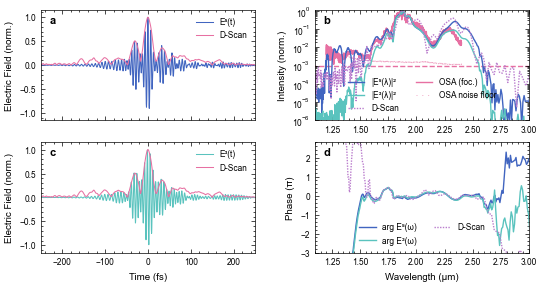

In [6]:
# =============================================================================
# FIGURE: COMBINED TIME DOMAIN (LEFT) + SPECTRUM AND PHASE (RIGHT)
# =============================================================================
triplet_index = 0
triplet_key = f'triplet_{triplet_index}'

phase_fit_wl_min = 1.6e-6
phase_fit_wl_max = 2.6e-6


def compute_spectrum_wavelength(time_arr, field_arr):
    """Normalized power spectrum on a wavelength axis.

    The FFT power S_f is converted with the Jacobian
    S_lambda = S_f * |df/dlambda| = S_f * c / lambda^2.
    """
    n = len(field_arr)
    dt = np.mean(np.diff(time_arr))
    freq_hz = np.fft.fftfreq(n, dt)
    fft_result = np.fft.fft(field_arr)

    pos_idx = freq_hz > 0
    freq_hz_pos = freq_hz[pos_idx]
    spec_f = np.abs(fft_result[pos_idx]) ** 2

    wl_m = c / freq_hz_pos
    spec_lambda = spec_f * c / wl_m ** 2

    sort_idx = np.argsort(wl_m)
    wl_um = wl_m[sort_idx] * 1e6
    spec_lambda = spec_lambda[sort_idx]

    if spec_lambda.max() > 0:
        spec_lambda = spec_lambda / spec_lambda.max()
    return wl_um, spec_lambda


def compute_corrected_phase(time_arr, field_arr, wl_min, wl_max):
    """Spectral phase with the linear term fitted over [wl_min, wl_max] removed."""
    n = len(field_arr)
    dt = np.mean(np.diff(time_arr))
    fft_result = np.fft.fft(np.fft.fftshift(field_arr))
    freq_hz = np.fft.fftfreq(n, dt)

    sort_idx = np.argsort(freq_hz)
    freq_sorted = freq_hz[sort_idx]
    unwrapped_phase = np.unwrap(np.angle(fft_result[sort_idx]))

    fit_idx = np.where((freq_sorted >= c / wl_max) & (freq_sorted <= c / wl_min))[0]
    if len(fit_idx) >= 2:
        coeffs = np.polyfit(freq_sorted[fit_idx], unwrapped_phase[fit_idx], 1)
        corrected_phase = unwrapped_phase - np.polyval(coeffs, freq_sorted)
    else:
        corrected_phase = unwrapped_phase

    pos_idx = freq_sorted > 0
    return freq_sorted[pos_idx] * 1e-12, corrected_phase[pos_idx]


# ---------- Time-domain data ----------
data_n5 = efield_data['method1_550'][triplet_key]
time_fs_n5 = data_n5['time'] * 1e15
field_n5 = data_n5['field']
field_norm_n5 = np.real(field_n5) / np.max(np.abs(field_n5))
intensity_norm_n5 = np.abs(field_n5) ** 2 / np.max(np.abs(field_n5) ** 2)
time_centered_n5 = time_fs_n5 - time_fs_n5[np.argmax(intensity_norm_n5)]

data_n3 = efield_data['method3_thg'][triplet_key]
time_fs_n3 = data_n3['time'] * 1e15
field_n3 = data_n3['field']
field_norm_n3 = np.real(field_n3) / np.max(np.abs(field_n3))
intensity_norm_n3 = np.abs(field_n3) ** 2 / np.max(np.abs(field_n3) ** 2)
time_centered_n3 = time_fs_n3 - time_fs_n3[np.argmax(intensity_norm_n3)]

dscan_int_norm = np.abs(dscan_field_complex) ** 2
dscan_int_norm = dscan_int_norm / dscan_int_norm.max()
dscan_env = np.sqrt(dscan_int_norm)

# ---------- Layout ----------
fig = plt.figure(figsize=(16 * cm, 8 * cm), constrained_layout=False)
gs = fig.add_gridspec(2, 2, width_ratios=[1.0, 1.0], height_ratios=[1.0, 1.0],
                      hspace=0.20, wspace=0.28)

ax_lt = fig.add_subplot(gs[0, 0])                 # a: N = 5 field
ax_lb = fig.add_subplot(gs[1, 0], sharex=ax_lt)   # c: N = 3 field
ax_rt = fig.add_subplot(gs[0, 1])                 # b: spectra
ax_rb = fig.add_subplot(gs[1, 1], sharex=ax_rt)   # d: spectral phase

fieldzoom_xmin, fieldzoom_xmax = -250, 250
field_ymin, field_ymax = -1.15, 1.15

# ---------- (a) N = 5 field ----------
ax_lt.plot(time_centered_n5, field_norm_n5, lw=0.75, color=cycle_colors[0], label='E⁵(t)')
ax_lt.plot(dscan_time * 1e15, dscan_env, lw=0.75, color=cycle_colors[1], label='D-Scan')
ax_lt.set_xlim(fieldzoom_xmin, fieldzoom_xmax)
ax_lt.set_ylim(field_ymin, field_ymax)
ax_lt.tick_params(axis='x', labelbottom=False)
ax_lt.set_ylabel('Electric Field (norm.)')
ax_lt.legend(fontsize=SMALL_SIZE, loc='upper right', frameon=False, ncol=1)

# ---------- (c) N = 3 field ----------
ax_lb.plot(time_centered_n3, field_norm_n3, lw=0.75, color=cycle_colors[2], label='E³(t)')
ax_lb.plot(dscan_time * 1e15, dscan_env, lw=0.75, color=cycle_colors[1], label='D-Scan')
ax_lb.set_xlim(fieldzoom_xmin, fieldzoom_xmax)
ax_lb.set_ylim(field_ymin, field_ymax)
ax_lb.set_xlabel('Time (fs)')
ax_lb.set_ylabel('Electric Field (norm.)')
ax_lb.legend(fontsize=SMALL_SIZE, loc='upper right', frameon=False, ncol=1)

# ---------- (b) Spectra ----------
for method, color, label in [('method1_550', cycle_colors[0], '|E⁵(λ)|²'),
                             ('method3_thg', cycle_colors[2], '|E³(λ)|²')]:
    if triplet_key not in efield_data[method]:
        continue
    data = efield_data[method][triplet_key]
    wl_um, spectrum_lambda = compute_spectrum_wavelength(data['time'], data['field'])
    ax_rt.plot(wl_um, spectrum_lambda, color=color, label=label)

wl_um_dscan, spectrum_lambda_dscan = compute_spectrum_wavelength(dscan_time, dscan_field_complex)
ax_rt.plot(wl_um_dscan, spectrum_lambda_dscan, color=cycle_colors[5],
           linestyle=linestyle_tuple[2][1], label='D-Scan')

osa_trace_name = '20250610_SIGCLIP'
if osa_trace_name in osa_data:
    osa = osa_data[osa_trace_name]
    wl_um_osa = osa['wavelength_nm'] * 1e-3
    pwr_norm_osa = 10 ** (osa['power_dBm'] / 10)
    osa_raw_ref = pwr_norm_osa.max()      # raw OSA peak, reference for the noise floor
    # Focus reshaping: the OSA sees the collimated beam, the field is sampled on
    # axis in the focus, where the on-axis intensity scales as 1/lambda^2.
    pwr_norm_osa = pwr_norm_osa / wl_um_osa ** 2
    pwr_norm_osa = pwr_norm_osa / pwr_norm_osa.max()
    ax_rt.plot(wl_um_osa, pwr_norm_osa, color=cycle_colors[1], label='OSA (foc.)', zorder=0)

# Instrument detection floor (2 nm resolution, 10 averages), not focus-reshaped
if 'noise_floor' in osa_data:
    nf = osa_data['noise_floor']
    ax_rt.plot(nf['wavelength_nm'] * 1e-3, 10 ** (nf['power_dBm'] / 10) / osa_raw_ref,
               color=cycle_colors[1], lw=0.7, ls=linestyle_tuple[1][1], alpha=0.6,
               label='OSA noise floor', zorder=0)

ax_rt.set_ylabel('Intensity (norm.)')
ax_rt.set_yscale('log')
ax_rt.set_xlim(1.1, 3)
ax_rt.set_ylim(1e-6, 1.1)
ax_rt.hlines(1e-3, 1, 3, colors=cycle_colors[1], linestyles='--', zorder=0)
ax_rt.legend(fontsize=SMALL_SIZE, loc='lower center', ncol=2, frameon=False)

# ---------- (d) Spectral phase ----------
for method, color, label in [('method1_550', cycle_colors[0], 'arg E⁵(ω)'),
                             ('method3_thg', cycle_colors[2], 'arg E³(ω)')]:
    if triplet_key not in efield_data[method]:
        continue
    data = efield_data[method][triplet_key]
    freq_thz, phase = compute_corrected_phase(data['time'], data['field'],
                                              phase_fit_wl_min, phase_fit_wl_max)
    ax_rb.plot(1e6 * c / (freq_thz * 1e12), phase / np.pi, color=color, label=label)

freq_dscan, phase_dscan = compute_corrected_phase(dscan_time, dscan_field_complex,
                                                  phase_fit_wl_min, phase_fit_wl_max)
ax_rb.plot(1e6 * c / (freq_dscan * 1e12), phase_dscan / np.pi, color=cycle_colors[5],
           linestyle=linestyle_tuple[2][1], label='D-Scan')

ax_rb.set_xlabel('Wavelength (µm)')
ax_rb.set_ylabel('Phase (π)')
ax_rb.set_xlim(1.1, 3)
ax_rb.set_ylim(-3, 2.8)
ax_rb.legend(fontsize=SMALL_SIZE, loc='lower center', ncol=2, frameon=False)

# ---------- Panel labels ----------
for _ax, _lbl in [(ax_lt, 'a'), (ax_rt, 'b'), (ax_lb, 'c'), (ax_rb, 'd')]:
    _ax.text(0.04, 0.95, _lbl, transform=_ax.transAxes, fontsize=BIGGER_SIZE,
             fontweight='bold', va='top', ha='left')

with plt.rc_context({'savefig.bbox': 'standard'}):
    plt.tight_layout()
    if saveplots:
        plt.savefig(
            f'{saveFigDir}comparison_combined_time_spec_phase_triplet_{triplet_index}.pdf',
            dpi=dpi_export)
plt.show()

## Time-frequency analysis

The retrieved traces contain a short, broadband main pulse followed by a long,
narrowband free-induction-decay tail. A single STFT window cannot resolve both:
a short window smears the narrow tail lines, a long window smears the main
pulse in time.

`compute_piecewise_stft` therefore runs the STFT piecewise with a
time-dependent window length and stitches the segments back together. The
window length follows a sigmoid that switches from 1024 to 4096 samples around
the end of the main pulse, trading time resolution for frequency resolution
exactly where the signal changes character.

In [7]:
# =============================================================================
# PIECEWISE STFT WITH A TIME-DEPENDENT WINDOW LENGTH
# =============================================================================


def compute_piecewise_stft(time_fs, sig, t_edges_fs, Nw_list, fs,
                           nfft=4096 * 4, win_type='hann'):
    """Compute an STFT segment by segment and stitch the segments together.

    Parameters
    ----------
    time_fs : array
        Time axis in fs.
    sig : array
        Signal to analyze.
    t_edges_fs : array
        Time edges (fs) separating the piecewise segments.
    Nw_list : sequence of int
        Window length used inside each segment (len(t_edges_fs) - 1 entries).
    fs : float
        Sampling frequency in samples/fs, so the frequency axis comes out in PHz.
    nfft : int
        FFT length (zero padding), shared by all segments so the frequency grids
        line up and can be concatenated.
    win_type : str
        Window passed to `scipy.signal.get_window`.

    Returns
    -------
    t_plot : array
        Stitched, time-sorted time axis.
    SdB_stitched : array
        Stitched spectrogram in dB (normalize downstream as appropriate).
    f_ref : array
        Frequency grid (PHz).
    order : array
        Sorting indices applied to the stitched time axis.
    """
    hop_list = [Nw // 16 for Nw in Nw_list]
    all_t = []
    all_SdB = []
    f_ref = None

    for (t0, t1, Nw, hop) in zip(t_edges_fs[:-1], t_edges_fs[1:], Nw_list, hop_list):
        i0 = np.searchsorted(time_fs, t0)
        i1 = np.searchsorted(time_fs, t1)

        # Pad the segment by one window so the STFT is not edge-limited inside
        # [t0, t1]; the padding is cropped away again below.
        pad = Nw
        j0 = max(0, i0 - pad)
        j1 = min(len(sig), i1 + pad)

        win = get_window(win_type, Nw)
        f, t_local, Z = stft(sig[j0:j1], fs=fs, window=win, nperseg=Nw,
                             noverlap=Nw - hop, nfft=nfft, boundary=None)
        SdB = 10 * np.log10(np.abs(Z) ** 2 + 1e-12)
        f_ref = f

        t_global = time_fs[j0] + t_local
        keep = (t_global >= t0) & (t_global <= t1)

        all_t.append(t_global[keep])
        all_SdB.append(SdB[:, keep])

    t_stitched = np.concatenate(all_t)
    SdB_stitched = np.concatenate(all_SdB, axis=1)

    order = np.argsort(t_stitched)
    return t_stitched[order], SdB_stitched, f_ref, order


def sigmoid(x, x0, k, y_min, y_max):
    """Sigmoid from y_min to y_max, centred at x0 with steepness k."""
    y = 1 / (1 + np.exp(-k * (x - x0)))
    return y * (y_max - y_min) + y_min


def make_nipy_mod_cmap():
    """`nipy_spectral` with its dark bottom replaced by white -> light purple."""
    n_hi, n_lo = 200, 60
    nipy_colors = plt.cm.nipy_spectral(np.linspace(0.18, 1.0, n_hi))  # skip dark 18%
    lo = np.column_stack([
        np.linspace(1.0, nipy_colors[0, 0], n_lo),   # R: white -> first nipy color
        np.linspace(1.0, nipy_colors[0, 1], n_lo),   # G
        np.linspace(0.95, nipy_colors[0, 2], n_lo),  # B (slight purple tint)
        np.ones(n_lo),
    ])
    lo[:n_lo // 3, 2] = np.linspace(1.0, 0.85, n_lo // 3)
    return LinearSegmentedColormap.from_list('nipy_mod', np.vstack([lo, nipy_colors]))


cmap_nipy_mod = make_nipy_mod_cmap()

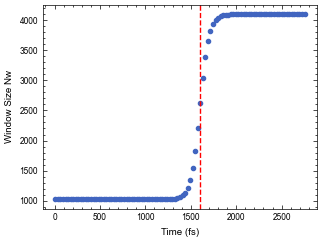

In [8]:
# =============================================================================
# FIGURE: STFT WINDOW-LENGTH SCHEDULE
# =============================================================================
triplet_index = 0
triplet_key = f'triplet_{triplet_index}'

# The window schedule is laid out on the N = 5 time axis and reused for both
# methods in the spectrogram comparison below.
time_fs = efield_data['method1_550'][triplet_key]['time'] * 1e15

k_ = 0.02                                     # sigmoid steepness (1/fs)
trnPt = 1600                                  # switch-over time (fs)
t_edges_fs = np.linspace(time_fs.min(), time_fs.max(), int(2 / k_))
Nw_list = np.rint(sigmoid(t_edges_fs[:-1], x0=trnPt, k=k_,
                          y_min=1024, y_max=4096)).astype(np.int64)

fig, ax = plt.subplots()
ax.scatter(t_edges_fs[:-1], Nw_list)
ax.axvline(trnPt, color='red', linestyle='dashed')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Window Size Nw')

plt.tight_layout()
if saveplots:
    plt.savefig(f'{saveFigDir}stft_window_schedule.pdf')
    plt.savefig(f'{saveFigDir}stft_window_schedule.png', dpi=dpi_export)
plt.show()

### Spectrogram comparison: N = 3 vs N = 5

Left panel: the gate transfer functions from above, clipped at −40 dB and drawn
on the same frequency axis as the spectrograms, so the detection bandwidth can
be read off directly against the signal content. Both spectrograms are
normalized to their own peak and share one colour scale; the right-hand axis
converts frequency to wavelength.

[|E³(t, ω)|²]  t: [-1337, 1218] fs   f: [0.000, 5.420] PHz   peak dB: 0.0
[|E⁵(t, ω)|²]  t: [-1338, 1217] fs   f: [0.000, 5.415] PHz   peak dB: 0.0


C:\Users\ritzkowf\AppData\Local\Temp\ipykernel_51440\2849515937.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


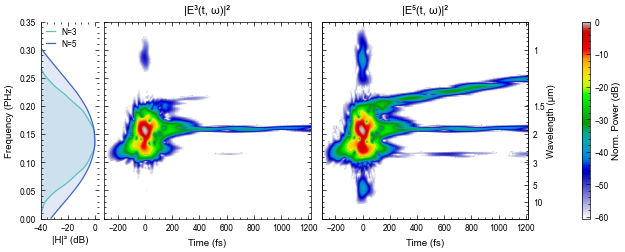

In [9]:
# =============================================================================
# FIGURE: SPECTROGRAM COMPARISON, N = 3 vs N = 5
#   layout:  |H|^2  ||  spec N=3 | spec N=5 | wavelength axis | colorbar
# =============================================================================
triplet_index = 0
triplet_key = f'triplet_{triplet_index}'
methods_to_compare = ['method3_thg', 'method1_550']
titles = ['|E³(t, ω)|²', '|E⁵(t, ω)|²']

thr_db = -60.5
top_db = 0.0
freq_ylim = (0, 0.35)      # PHz
bw_clip = -40.0            # dB floor of the transfer-function panel

# Gate transfer functions, each referenced to its own peak
H_mags = [H_mag_n3_gatenorm_dB - np.max(H_mag_n3_gatenorm_dB),
          H_mag_n5_gatenorm_dB - np.max(H_mag_n5_gatenorm_dB)]
freq_bw = freq_thz_gate / 1000.0                 # THz -> PHz
tf_colors = [cycle_colors[2], cycle_colors[0]]   # N=3, N=5
tf_labels = ['N=3', 'N=5']

fig = plt.figure(figsize=(cm * 18, cm * 6.5))

# Outer grid separates the transfer-function panel from the spectrograms; the
# inner grid holds both spectrograms, a spacer for the wavelength axis, and the
# colorbar.
outer = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[0.12, 1.0], wspace=0.02)
ax_tf = fig.add_subplot(outer[0, 0])

inner = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[0, 1],
                                         width_ratios=[1.0, 1.0, 0.15, 0.04],
                                         wspace=0.10)
ax_s0 = fig.add_subplot(inner[0, 0])
ax_s1 = fig.add_subplot(inner[0, 1], sharey=ax_s0)
ax_cb = fig.add_subplot(inner[0, 3])
spec_axes = [ax_s0, ax_s1]

# ---- Spectrograms ----
pcm_last = None
for i, method in enumerate(methods_to_compare):
    if triplet_key not in efield_data[method]:
        continue

    data = efield_data[method][triplet_key]
    time_fs_m = data['time'] * 1e15
    x = np.real(data['field'])
    fs = 1 / (time_fs_m[1] - time_fs_m[0])

    t_plot, SdB_stitched, f_ref, order = compute_piecewise_stft(
        time_fs_m, x, t_edges_fs, Nw_list, fs)

    peak_time = time_fs_m[np.argmax(np.abs(data['field']) ** 2)]
    t_plot_centered = t_plot - peak_time
    SdB_stitched -= np.max(SdB_stitched)
    SdB_masked = np.ma.masked_less(SdB_stitched, thr_db)

    ax = spec_axes[i]
    pcm_last = ax.pcolormesh(t_plot_centered, f_ref, SdB_stitched,
                             shading='gouraud', cmap=cmap_nipy_mod,
                             vmin=thr_db, vmax=top_db, rasterized=True)
    ax.contour(t_plot_centered, f_ref, SdB_masked, levels=np.arange(-60, 10, 10),
               colors='0.35', linewidths=0.20, antialiased=True)

    ax.set_xlim(-300, np.max(t_plot_centered))
    ax.set_ylim(*freq_ylim)
    ax.set_xlabel('Time (fs)')
    ax.set_title(titles[i])
    ax.tick_params(labelleft=False)

    print(f"[{titles[i]}]  t: [{t_plot_centered.min():.0f}, {t_plot_centered.max():.0f}] fs   "
          f"f: [{f_ref.min():.3f}, {f_ref.max():.3f}] PHz   peak dB: {SdB_masked.max():.1f}")

# ---- Right-hand wavelength axis ----
# Fixed ticks placed at the frequency positions of chosen wavelengths; a
# functional axis would hit the f -> 0 singularity and request millions of ticks.
_c_um_phz = c * 1e-9                       # lambda[um] = _c_um_phz / f[PHz]
ax_wl = ax_s1.twinx()
ax_wl.set_ylim(*freq_ylim)
_wl_ticks_um = [1, 1.5, 2, 3, 5, 10]
ax_wl.set_yticks([_c_um_phz / w for w in _wl_ticks_um])
ax_wl.set_yticklabels([f"{w:g}" for w in _wl_ticks_um])
ax_wl.set_ylabel('Wavelength (µm)', labelpad=2)

# ---- Transfer-function panel ----
ax_tf.set_ylim(*freq_ylim)
ax_tf.set_ylabel('Frequency (PHz)')
ax_tf.set_xlabel('|H|² (dB)', labelpad=2)

for i, H_dB in enumerate(H_mags):
    H_clip = np.clip(H_dB, bw_clip, 0)
    ax_tf.fill_betweenx(freq_bw, bw_clip, H_clip, color=tf_colors[i], alpha=0.15, lw=0)
    ax_tf.plot(H_clip, freq_bw, color=tf_colors[i], lw=0.9, label=tf_labels[i])

ax_tf.set_xlim(bw_clip, 3)
ax_tf.set_xticks([-40, -20, 0])
ax_tf.legend(loc='upper left', frameon=False, fontsize=SMALL_SIZE,
             handlelength=1.0, borderpad=0.2, labelspacing=0.3)
ax_tf.spines['top'].set_visible(False)
ax_tf.spines['right'].set_visible(False)

# ---- Colorbar ----
cbar = fig.colorbar(pcm_last, cax=ax_cb)
cbar.set_label('Norm. Power (dB)', labelpad=2)
cbar.set_ticks(np.arange(-60, 10, 10))
if getattr(cbar, 'solids', None) is not None:
    cbar.solids.set_rasterized(True)

fig.tight_layout()
plt.show()

if saveplots:
    fig.savefig(f'{saveFigDir}spectrogram_compar_n3_n5.pdf', dpi=300)
    fig.savefig(f'{saveFigDir}spectrogram_compar_n3_n5.png', dpi=300)